# 01 · Tour of tasks

A **task** is the kind of question you ask about a photo: *where are the objects?*, *what is
the exact outline of this object?*, *how far away is each pixel?*... In this notebook you try
each task once, on real photos, with the model VisionServe uses for it.

**What you will learn**

- what each task does and what its answer looks like
- which model to use for which task
- how to read and draw each kind of answer

**Time needed:** about 40 minutes (each section is short; you can stop after any section).

**What you need before you start**

- notebook [00 · Overview and quick start](00-overview-and-quickstart.ipynb) (connect, predict, `bbox`)
- a running server. The models are downloaded the first time (about 2 GB for all sections).
  A GPU makes it faster, but a CPU works too.

**Steps**

1. Object detection: `rf-detr`
2. Open-vocabulary detection: `grounding-dino`
3. Segmentation: `mobile-sam` (box, point, and "everything")
4. Text to outlines: `grounded-sam`
5. Depth: `midas`
6. Faces: `scrfd`
7. Reading text (OCR): `paddle-ocr`
8. Classification: `efficientnet-b0`
9. Compare a photo with sentences: `clip` and `clip-text`

## Setup

Load the helper functions and connect to the server (as in notebook 00).

In [1]:
from PIL import Image
from handson import connect, ensure_model, photo, show, show_side_by_side, mark, print_json, table

client = connect()

Connected to VisionServe at http://127.0.0.1:11435: {'status': 'ok'}


**What you see**

*Connected to VisionServe at ...*. If you see an error, start the server first (see the README).

<details><summary><b>In detail</b></summary>

Every section below starts with `ensure_model(...)`, so it downloads only the model it needs.
To download all models now, run `visionserve pull NAME` for each name in the steps list
(in Docker: `docker exec visionserve visionserve pull NAME`).

</details>

## 1. Object detection: "what is here, and where?"

An **object detector** finds objects and draws a **box** around each one. It also gives the
**class** (the kind of object) and a **confidence** (a score from 0 to 1).

`rf-detr` knows a **fixed list** of 80 everyday classes (person, dog, cup, car, chair...). It
cannot find a class that is not in its list. This is called a **closed-set** detector.

Model 'rf-detr' is installed (state: loaded).
person  0.94  bbox=[442, 32, 85, 132]
dog     0.92  bbox=[216, 227, 57, 92]
dog     0.90  bbox=[281, 109, 33, 79]
person  0.90  bbox=[544, 26, 65, 145]
dog     0.89  bbox=[427, 192, 39, 85]
dog     0.89  bbox=[226, 138, 42, 91]
bench   0.50  bbox=[515, 78, 125, 86]


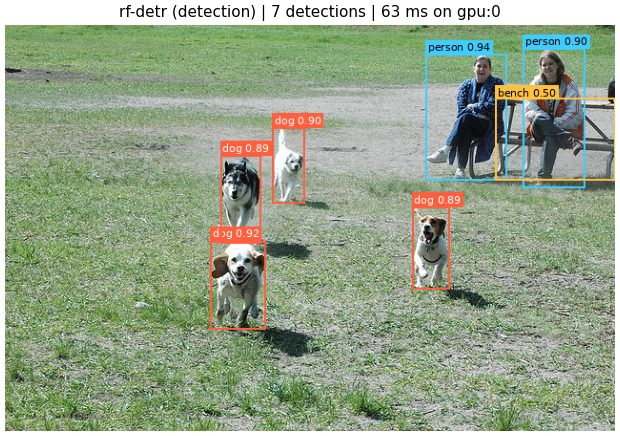

In [2]:
ensure_model(client, "rf-detr")

res = client.predict("rf-detr", photo("dogs"))
for d in res.detections:
    print(f"{d.cls:7s} {d.conf:.2f}  bbox={[round(v) for v in d.bbox]}")
show(photo("dogs"), res)

**What you see**

Four dogs, two people and a bench, each with a box and a score. The dogs and the people have
high scores (about 0.9). The bench has a lower score (about 0.5): it is partly hidden, so the
model is less sure.

<details><summary><b>In detail</b></summary>

- RF-DETR is a *transformer* detector (a type of neural network). It predicts a fixed set of
  candidate objects in one step, so it needs no extra clean-up step ("non-maximum
  suppression") like YOLO-type detectors.
- The minimum score (`conf_threshold`) is fixed in the model's `manifest.yaml`. To keep fewer
  objects, filter on your side: `res.filter_by_conf(0.8)`.
- Smaller and faster: `rf-detr-nano` (notebook 00). See [Object detection](https://mtbui2010.github.io/vision_serve/concepts/tasks/#object-detection-what-is-here-and-where)
  and [Models and performance](https://mtbui2010.github.io/vision_serve/reference/models/).

</details>

## 2. Open-vocabulary detection: "find the things I name"

What if your object is not one of the 80 classes? An **open-vocabulary** detector takes your
words as a **prompt** (text input) and looks for them. `grounding-dino` reads the photo and the
words together.

Write the names with a **dot after each name**: `"broccoli. carrot. kiwi fruit."`. Each name
can have several words.

Model 'grounding-dino' is installed (state: loaded).


orange pepper  0.88
rice           0.61
kiwi fruit     0.57
broccoli       0.49
kiwi fruit     0.44
carrot         0.38
fig            0.36
fig            0.35
kiwi fruit     0.33


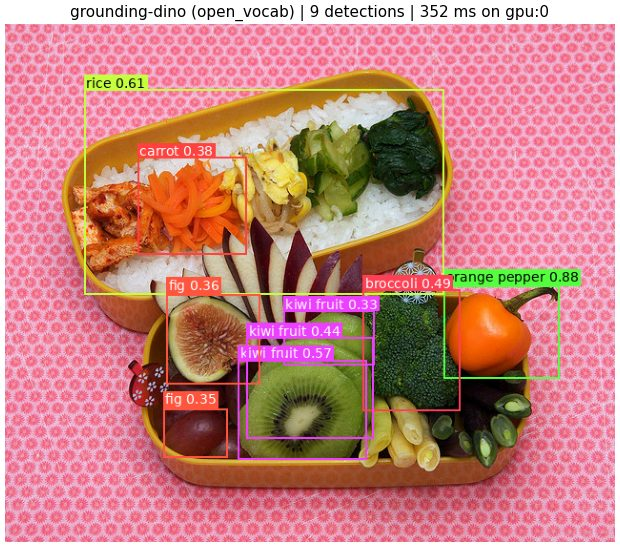

In [3]:
ensure_model(client, "grounding-dino")

words = "broccoli. carrot. kiwi fruit. fig. rice. orange pepper."
res = client.predict("grounding-dino", photo("food"), prompt=words)
for d in sorted(res.detections, key=lambda d: -d.conf):
    print(f"{d.cls:14s} {d.conf:.2f}")
show(photo("food"), res)

**What you see**

Boxes with **your** words as labels. "kiwi fruit", "fig" and "orange pepper" are not in the
80 classes of `rf-detr`, but this model still finds them. Most scores are lower than in
section 1 (many are between 0.3 and 0.6); this is normal for this kind of model. A word can get
more than one box. Look closely: the lower "fig" box is on the grapes. Boxes with low scores
are more often wrong.

<details><summary><b>In detail</b></summary>

- Only boxes with a score above `box_threshold` (default 0.3) are kept. Notebook 02 shows how
  this number changes the answer.
- Upper and lower case do not matter. The Python client also accepts commas: `"cat, dog"`
  becomes `"cat. dog."`. See [`prompt`](https://mtbui2010.github.io/vision_serve/clients/python/#prompt-text).
- Open-vocabulary models are slower than `rf-detr` (they also process the words). For speed,
  `rfdetr-gdino` uses RF-DETR for the 80 known classes and GroundingDINO only for the other
  words. See [Open-vocabulary detection](https://mtbui2010.github.io/vision_serve/concepts/tasks/#open-vocabulary-detection-find-the-things-i-name).

</details>

## 3. Segmentation: "the exact outline of this object"

A box is a rough answer. A **mask** is exact: for every pixel it says *yes, this pixel is part
of the object* or *no*. Finding masks is called **segmentation**.

`mobile-sam` (a small "Segment Anything" model) cuts out the object that **you point at**. You
give it one of these prompts:

- a **box** `[x, y, w, h]` around the object, or
- a **point** `[x, y]` on the object.

The helper `mark()` draws your prompt on the photo, so you can see what you sent.

Model 'mobile-sam' is installed (state: loaded).


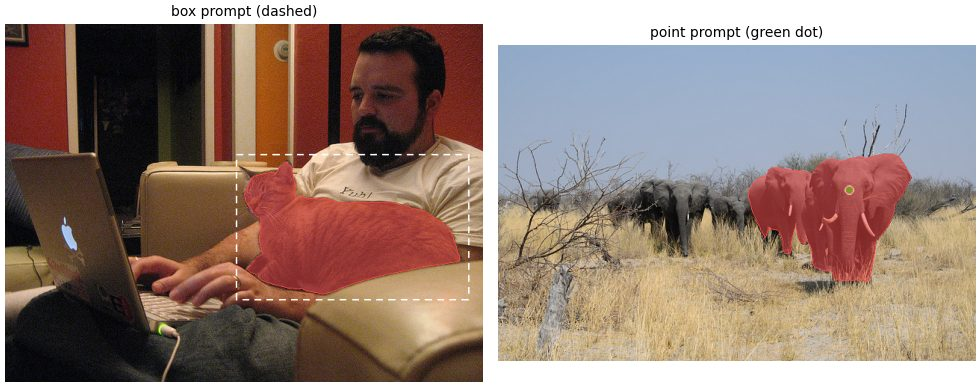

mask shape: (480, 640) | cat pixels: 29453 | 9.6 % of the photo
mask bbox: [320.0, 186.0, 290.0, 177.0] | mask score: 0.998


In [4]:
ensure_model(client, "mobile-sam")

box = [310, 175, 310, 195]                      # around the cat: x, y, w, h
res_box = client.predict("mobile-sam", photo("cat"), box=box)

point = [470, 195]                              # one pixel on the elephant
res_point = client.predict("mobile-sam", photo("elephant"), point=point)

show_side_by_side([(mark(photo("cat"), boxes=box), res_box),
                   (mark(photo("elephant"), points=point), res_point)],
                  titles=["box prompt (dashed)", "point prompt (green dot)"])

w, h = Image.open(photo("cat")).size
cat_mask = res_box.masks[0].to_ndarray(w, h)    # True/False for each pixel
print("mask shape:", cat_mask.shape, "| cat pixels:", int(cat_mask.sum()),
      f"| {100 * cat_mask.mean():.1f} % of the photo")
print("mask bbox:", res_box.masks[0].bbox, "| mask score:", round(res_box.masks[0].conf, 3))

**What you see**

- Left: the dashed box is what we sent; the colored area is the mask of the cat. It follows the
  cat's shape, not the box.
- Right: one green dot was enough to cut out the elephant. But the mask also covers the
  elephant just behind it: from one point, the model cannot know that you want only one of
  them. Notebook 02 shows how a second point ("not this one") fixes this.
- The printed mask is a grid of `True`/`False` with the photo's size (480 rows, 640 columns).
  The mask's `bbox` is the tight box around the mask pixels (it is smaller than our box).

<details><summary><b>In detail</b></summary>

- In the JSON a mask is not a list of pixels; it is compressed as **RLE** (run-length
  encoding: "so many pixels no, so many pixels yes, ..."), column by column.
  `mask.to_ndarray(width, height)` turns it into a numpy array. Always pass **your photo's**
  size.
- Several boxes give several masks (one per box). Several points describe **one** object;
  a point with label 0 means "not this part" (notebook 02).
- Other segmentation models: `sam2` (more accurate), `efficient-sam`. See
  [Segmentation](https://mtbui2010.github.io/vision_serve/concepts/tasks/#segmentation-the-exact-outline-of-this-object) and
  [`box`](https://mtbui2010.github.io/vision_serve/clients/python/#box-boxes) / [`point`](https://mtbui2010.github.io/vision_serve/clients/python/#point-points).

</details>

**Segment everything.** Without any prompt, `mobile-sam` tries a grid of points over the whole
photo and keeps the good masks that do not overlap. This is slower (hundreds of small runs),
so we use a smaller copy of the photo here.

48 masks in 1179 ms


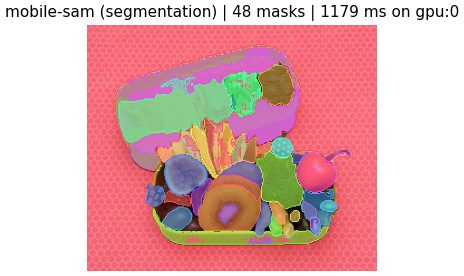

In [5]:
small = Image.open(photo("food")).resize((320, 272))
res_all = client.predict("mobile-sam", small)
print(len(res_all.masks), "masks in", round(res_all.duration_ms), "ms")
show(small, res_all, max_width=500)

**What you see**

Many masks in different colors: fruits, vegetables, the box, parts of the background. The
model does not know names; it only finds regions that look like one thing.

<details><summary><b>In detail</b></summary>

- The grid is 16 x 16 points by default (256 small model runs). `grid_size=8` is about 4 times
  faster and finds fewer, larger regions. See [`grid_size`](https://mtbui2010.github.io/vision_serve/clients/python/#grid_size).
- To get names **and** outlines, use the next section.

</details>

## 4. Text to outlines: `grounded-sam`

`grounded-sam` chains two models in one request: GroundingDINO finds **boxes** for your words,
then MobileSAM turns each box into a **mask**. Words in, outlines out.

The answer has a list of detections **and** a list of masks, in the same order: mask number 0
belongs to detection number 0.

Model 'grounded-sam' is installed (state: loaded).


dog     0.82  box=[427, 193, 39, 84]
person  0.86  box=[544, 26, 65, 145]
dog     0.76  box=[216, 228, 58, 92]
dog     0.76  box=[281, 109, 35, 78]
dog     0.75  box=[226, 139, 42, 90]
person  0.88  box=[442, 32, 84, 133]
bench   0.54  box=[483, 77, 157, 90]
bench   0.31  box=[484, 117, 155, 49]


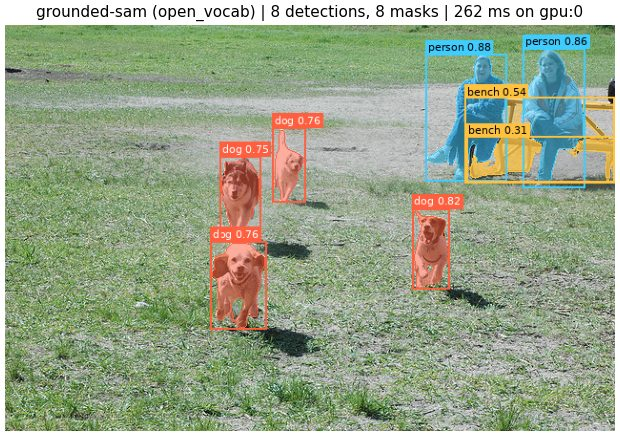

In [6]:
ensure_model(client, "grounded-sam")

res = client.predict("grounded-sam", photo("dogs"), prompt="dog. person. bench.")
for d, m in zip(res.detections, res.masks):
    print(f"{d.cls:7s} {d.conf:.2f}  box={[round(v) for v in d.bbox]}")
show(photo("dogs"), res)

**What you see**

Each dog, person and bench has a box with its word and a colored mask. Objects with the same
word have the same color. One request did both steps.

<details><summary><b>In detail</b></summary>

- `zip(res.detections, res.masks)` pairs each detection with its mask.
- Because it runs two models, it is slower than either one alone. For speed with known classes:
  `rfdetr-gdino-sam`. See [Grounded-SAM](https://mtbui2010.github.io/vision_serve/concepts/tasks/#grounded-sam-outline-everything-i-name) and
  [Pipelines](https://mtbui2010.github.io/vision_serve/architecture/pipelines/).

</details>

## 5. Depth: "how far away is each pixel?"

A **depth** model estimates, for every pixel, how far it is from the camera, from **one** normal
photo. The answer is a **depth map**: a grid of numbers.

Important: `midas` gives **relative** depth. A larger number means *nearer*, but the numbers
have no unit. They are **not** meters.

Model 'midas' is installed (state: loaded).
depth map size: 256 x 256
smallest: 0.0 largest: 1.0


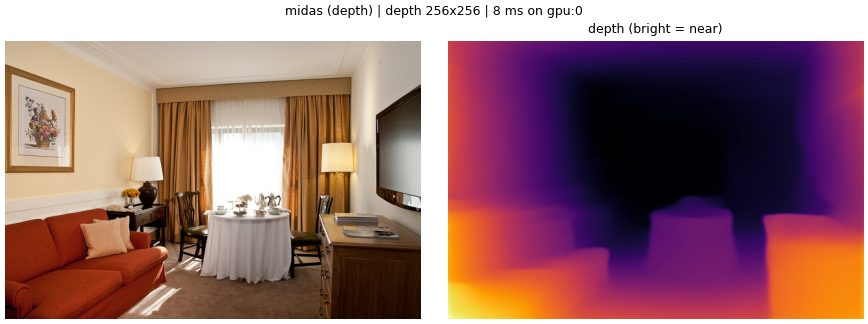

In [7]:
ensure_model(client, "midas")

res = client.predict("midas", photo("living-room"))
depth = res.depth_array()                       # numpy array, (rows, columns)
print("depth map size:", res.depth_width, "x", res.depth_height)
print("smallest:", round(float(depth.min()), 2), "largest:", round(float(depth.max()), 2))
show(photo("living-room"), res)

**What you see**

Left the photo, right the depth map. **Bright = near, dark = far.** The floor and the sofa near
the camera are bright; the far wall and the window are dark. The map is 256 x 256 (the model's
own size), not the photo's size, and its values go from 0 to 1.

<details><summary><b>In detail</b></summary>

- The depth map is in the model's resolution. To use it on the photo, resize it to the photo's
  size (the `show` helper does this for the picture).
- For distances in meters you need a depth camera (an RGB-D camera: it gives color and depth). Notebook 08 shows how depth
  is used for robots.
- `depth-anything-v2` is more accurate and slower. See [Depth](https://mtbui2010.github.io/vision_serve/concepts/tasks/#depth-how-far-is-each-pixel).

</details>

## 6. Faces: `scrfd`

`scrfd` is a detector for one class only: **face**. The answer is a normal detection list.

Model 'scrfd' is installed (state: loaded).
face 0.9 [293, 111, 48, 64]


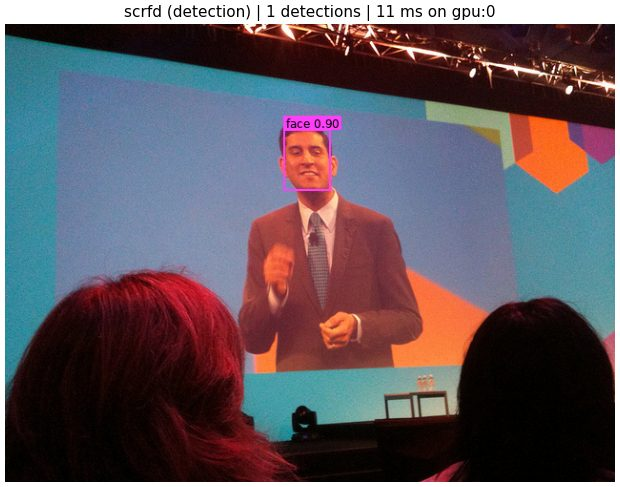

In [8]:
ensure_model(client, "scrfd")

res = client.predict("scrfd", photo("person"))
for d in res.detections:
    print(d.cls, round(d.conf, 2), [round(v) for v in d.bbox])
show(photo("person"), res)

**What you see**

One box around the face, with the class `face` and a score of about 0.9.

<details><summary><b>In detail</b></summary>

- Face detection finds **where** faces are. It does not recognize **who** it is.
- Use it, for example, to blur faces before you store photos. See
  [Faces and text](https://mtbui2010.github.io/vision_serve/concepts/tasks/#faces-and-text).

</details>

## 7. Reading text (OCR): `paddle-ocr`

**OCR** (optical character recognition) finds lines of text in a picture and reads them. We
make a small picture with text ourselves, with the PIL library, so we know the right answer.

For OCR, each detection's `cls` is **the text that was read**, and `bbox` is the box around
that line.

Model 'paddle-ocr' is installed (state: loaded).
read: 'VisionServe hands-on'       conf=0.99
read: 'Coffee 2.50 Tea 1.80'       conf=0.98
read: 'Total:4.30EUR'              conf=0.99


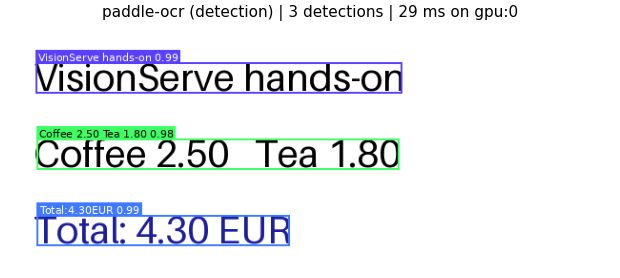

In [9]:
from PIL import ImageDraw, ImageFont

note = Image.new("RGB", (640, 260), "white")
pen = ImageDraw.Draw(note)
font = ImageFont.load_default(size=40)          # needs Pillow 10.1 or newer
pen.text((30, 30), "VisionServe hands-on", fill="black", font=font)
pen.text((30, 110), "Coffee 2.50   Tea 1.80", fill="black", font=font)
pen.text((30, 190), "Total: 4.30 EUR", fill=(30, 30, 160), font=font)

ensure_model(client, "paddle-ocr")
res = client.predict("paddle-ocr", note)
for d in res.detections:
    print(f"read: {d.cls!r:28s} conf={d.conf:.2f}")
show(note, res, max_width=640)

**What you see**

Three lines found, one box per line. The text is read correctly. Look closely: the spaces are
not always kept (`Total:4.30EUR`), and several spaces become one. OCR reads characters well,
but spaces are hard.

<details><summary><b>In detail</b></summary>

- The picture is made in memory and sent as a PNG file; you do not need to save it first.
- OCR works best on straight, sharp text. On photos of signs or receipts, a larger photo helps.
  See [Faces and text](https://mtbui2010.github.io/vision_serve/concepts/tasks/#faces-and-text).

</details>

## 8. Classification: "what is this picture about?"

A **classifier** gives labels for the **whole** picture, with no boxes. `efficientnet-b0`
chooses from the 1000 classes of ImageNet (a famous photo collection) and returns the **top 5**
labels.

Model 'efficientnet-b0' is installed (state: loaded).
tusker             0.458
African elephant   0.454
Indian elephant    0.024
water buffalo      0.002
warthog            0.001


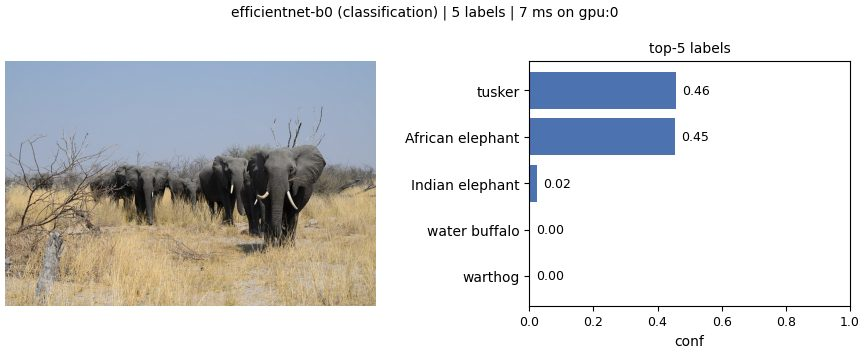

In [10]:
ensure_model(client, "efficientnet-b0")

res = client.predict("efficientnet-b0", photo("elephant"))
for c in res.classifications:
    print(f"{c.cls:18s} {c.conf:.3f}")
show(photo("elephant"), res)

**What you see**

The photo and, on the right, five bars. The best labels are elephant types ("tusker" means an
elephant with long tusks, "African elephant"). The scores of all 1000 classes add up to 1, so
two similar labels share the score.

<details><summary><b>In detail</b></summary>

- A classifier is good for "which kind of photo is this?". To find **where** things are, use a
  detector.
- `mobilenet-v3` is another classifier. See
  [Classification and embeddings](https://mtbui2010.github.io/vision_serve/concepts/tasks/#classification-and-embeddings-what-is-this-picture-about).

</details>

## 9. Compare a photo with sentences: CLIP

**CLIP** turns a photo, or a sentence, into an **embedding**: a list of 512 numbers that
describes its meaning. A photo and a sentence that mean the same thing get similar lists.

We compare them with the **cosine similarity**: a number that is larger when two lists "point
in the same direction". So we can ask *which sentence fits this photo best?*, with sentences we
write ourselves. This is called **zero-shot** classification (no training for our labels).

- `clip` makes the photo's embedding.
- `clip-text` makes one embedding per sentence. Separate the sentences with `". "`.

Model 'clip' is installed (state: loaded).
Model 'clip-text' is installed (state: loaded).


photo,a photo of a kitchen,a photo of a living room,a photo of an office desk,a photo of dogs on grass,a photo of food in a lunch box
kitchen,0.279,0.217,0.22,0.093,0.148
desk,0.214,0.234,0.278,0.117,0.183
food,0.223,0.165,0.192,0.137,0.318


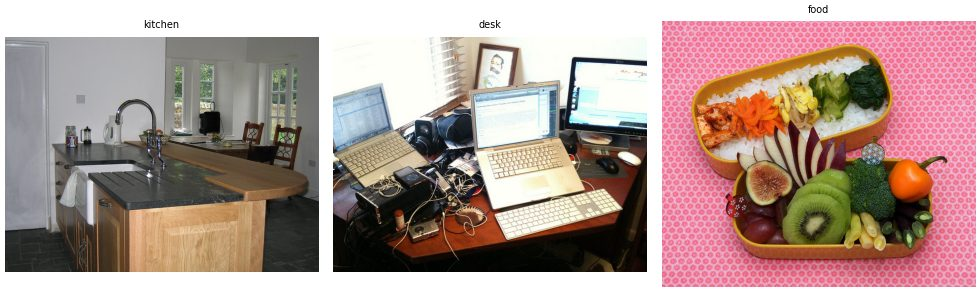

In [11]:
import numpy as np

ensure_model(client, "clip")
ensure_model(client, "clip-text")

captions = ["a photo of a kitchen", "a photo of a living room", "a photo of an office desk",
            "a photo of dogs on grass", "a photo of food in a lunch box"]
txt = client.predict("clip-text", photo("kitchen"), prompt=". ".join(captions)).embeddings_array()
txt = txt / np.linalg.norm(txt, axis=1, keepdims=True)      # length 1, so a dot product = cosine

rows = []
for key in ["kitchen", "desk", "food"]:
    img = client.predict("clip", photo(key)).embeddings_array()
    img = img / np.linalg.norm(img, axis=1, keepdims=True)
    cos = (img @ txt.T)[0]                                    # one number per caption
    rows.append([key] + [round(float(c), 3) for c in cos])
table(rows, ["photo"] + captions)
show_side_by_side([photo("kitchen"), photo("desk"), photo("food")], titles=["kitchen", "desk", "food"])

**What you see**

A table: one row per photo, one column per caption. In each row the **largest** number is the
caption that fits best: kitchen for the kitchen photo, office desk for the desk, lunch box for
the food. The numbers are small (0.1 to 0.3); only the **order** matters.

<details><summary><b>In detail</b></summary>

- `clip-text` needs a photo in the request, but it does not use it.
- Do not put a `.` inside a caption: the server splits the prompt at each dot.
- To turn the cosines into probabilities, CLIP uses `softmax(100 * cosine)` (softmax is a
  function that turns scores into probabilities that add up to 1). See the recipe
  [Zero-shot ranking with CLIP](https://mtbui2010.github.io/vision_serve/clients/python/#zero-shot-ranking-with-clip).
- Embeddings are also useful to search photos by text, or to find similar photos.
  `siglip-image` / `siglip-text` are another pair.

</details>

## Recap

| Task | Model | Prompt | Answer field |
|---|---|---|---|
| Object detection (80 classes) | `rf-detr`, `rf-detr-nano` | none | `detections` |
| Open-vocabulary detection | `grounding-dino` | words: `"cat. red cup."` | `detections` |
| Segmentation | `mobile-sam` | `box=` or `point=` (or none: everything) | `masks` |
| Text to outlines | `grounded-sam` | words | `detections` + `masks` (same order) |
| Depth (relative) | `midas` | none | `depth_map` (`depth_array()`) |
| Faces | `scrfd` | none | `detections` (class `face`) |
| Reading text | `paddle-ocr` | none | `detections` (class = the text) |
| Classification | `efficientnet-b0` | none | `classifications` (top 5) |
| Photo vs sentences | `clip` + `clip-text` | sentences | `embeddings` |

All models answer with the same `Result` object; only the fields for the task are filled.

## Next

- **[02 · Parameters](02-parameters.ipynb)**: the options of `predict` (thresholds, size
  filters, regions, prompts...) with before/after pictures.
- **[08 · Robotics](08-robotics.ipynb)**: depth, grasps and the support surface.
- Read more: [What the models do](https://mtbui2010.github.io/vision_serve/concepts/tasks/) and the [model gallery](https://mtbui2010.github.io/vision_serve/gallery/).